In [ ]:
# Run this first in Colab — installs everything needed
!pip install xgboost imbalanced-learn shap -q

In [ ]:
# If you want to save your work / load data from Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load the training dataset
train_df = pd.read_csv('/content/drive/MyDrive/UNSW_NB15_training-set.csv')
print('Training dataset loaded. First 5 rows:')
display(train_df.head())

# Load the testing dataset
test_df = pd.read_csv('/content/drive/MyDrive/UNSW_NB15_testing-set.csv')
print('\nTesting dataset loaded. First 5 rows:')
display(test_df.head())

Training dataset loaded. First 5 rows:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0



Testing dataset loaded. First 5 rows:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
train_df['proto'].unique()
print(f"Number of unique protocols: {train_df['proto'].nunique()}")

Number of unique protocols: 131


In [ ]:
print(train_df['service'].unique())
print(f"Number of unique services: {train_df['service'].nunique()}")

['-' 'http' 'ftp' 'ftp-data' 'smtp' 'pop3' 'dns' 'snmp' 'ssl' 'dhcp' 'irc'
 'radius' 'ssh']
Number of unique services: 13


In [ ]:
print(train_df['state'].unique())
print(f"Number of unique states: {train_df['state'].nunique()}")

['INT' 'FIN' 'REQ' 'ACC' 'CON' 'RST' 'CLO']
Number of unique states: 7


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              accuracy_score)
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print(f"NumPy:      {np.__version__}")
print(f"Pandas:     {pd.__version__}")
print(f"XGBoost:    {xgb.__version__}")
print(f"TensorFlow: {tf.__version__}")
print("✅ All libraries loaded.")

NumPy:      2.0.2
Pandas:     2.2.2
XGBoost:    3.2.0
TensorFlow: 2.19.0
✅ All libraries loaded.


In [ ]:
print("=== MISSING VALUES ===")
missing = train_df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "None found ✅")

print("\n=== DATA TYPES ===")
print(train_df.dtypes)

print("\n=== CLASS DISTRIBUTION ===")
print(train_df['label'].value_counts())
print(f"\nAttack ratio: {train_df['label'].mean():.2%}")

print("\n=== ATTACK CATEGORIES ===")
print(train_df['attack_cat'].value_counts())

=== MISSING VALUES ===
None found ✅

=== DATA TYPES ===
id                     int64
dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl    

In [ ]:
def preprocess(df, encoders=None, fit=True):
    df = df.copy()

    # Drop only the id column; keep attack_cat for multi-class
    df.drop(columns=['id'], inplace=True, errors='ignore')

    # Fill missing values
    df.fillna(0, inplace=True)

    # Encode categorical columns
    cat_cols = ['proto', 'service', 'state']
    encoders = encoders or {}

    for col in cat_cols:
        if col not in df.columns:
            continue
        if fit:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
        else:
            le = encoders[col]
            df[col] = df[col].astype(str).apply(
                lambda x: x if x in le.classes_ else le.classes_[0]
            )
            df[col] = le.transform(df[col])

    return df, encoders


train_clean, encoders = preprocess(train_df.copy(), fit=True)
test_clean,  _        = preprocess(test_df.copy(),  encoders=encoders, fit=False)

In [ ]:
attack = train_clean['attack_cat']

In [ ]:
attack

,attack_cat
0,Normal
1,Normal
2,Normal
3,Normal
4,Normal
...,...
82327,Normal
82328,Normal
82329,Normal
82330,Normal


In [ ]:
print(attack.isnull().sum())

0


In [ ]:
def preprocess(df, encoders=None, fit=True):
    df = df.copy()

    # Drop only the id column; keep attack_cat for multi-class
    df.drop(columns=['id'], inplace=True, errors='ignore')

    # Fill missing values
    df.fillna(0, inplace=True)

    # Encode categorical columns
    cat_cols = ['proto', 'service', 'state']
    encoders = encoders or {}

    for col in cat_cols:
        if col not in df.columns:
            continue
        if fit:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
        else:
            le = encoders[col]
            df[col] = df[col].astype(str).apply(
                lambda x: x if x in le.classes_ else le.classes_[0]
            )
            df[col] = le.transform(df[col])

    return df, encoders


train_clean, encoders = preprocess(train_df.copy(), fit=True)
test_clean,  _        = preprocess(test_df.copy(),  encoders=encoders, fit=False)

# ── Binary labels ─────────────────────────────────────────────────────────────
X_train = train_clean.drop(['label', 'attack_cat'], axis=1)
y_train = train_clean['label']
X_test  = test_clean.drop(['label', 'attack_cat'], axis=1)
y_test  = test_clean['label']

# ── Multi-class labels (attack_cat) ──────────────────────────────────────────
# Normalise: strip whitespace, title-case, replace NaN/blank with "Normal"
def clean_attack_cat(s):
    s = str(s).strip()
    return s if s not in ('', 'nan') else 'Normal'

train_clean['attack_cat'] = train_clean['attack_cat'].apply(clean_attack_cat)
test_clean['attack_cat']  = test_clean['attack_cat'].apply(clean_attack_cat)

le_cat = LabelEncoder()
y_train_mc = le_cat.fit_transform(train_clean['attack_cat'])
y_test_mc  = le_cat.transform(
    test_clean['attack_cat'].apply(
        lambda x: x if x in le_cat.classes_ else 'Normal'
    )
)
mc_classes = le_cat.classes_
print(f"Multi-class labels ({len(mc_classes)}): {list(mc_classes)}")

print(f"\nX_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print(f"y_train_mc: {y_train_mc.shape} | y_test_mc: {y_test_mc.shape}")


Multi-class labels (10): ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']

X_train: (82332, 42) | y_train: (82332,)
X_test:  (175341, 42)  | y_test:  (175341,)
y_train_mc: (82332,) | y_test_mc: (175341,)


In [ ]:
y_train_mc

array([6, 6, 6, ..., 6, 6, 6])

In [ ]:
y_test_mc

array([6, 6, 6, ..., 5, 5, 5])

In [ ]:
encoders

{'proto': LabelEncoder(), 'service': LabelEncoder(), 'state': LabelEncoder()}

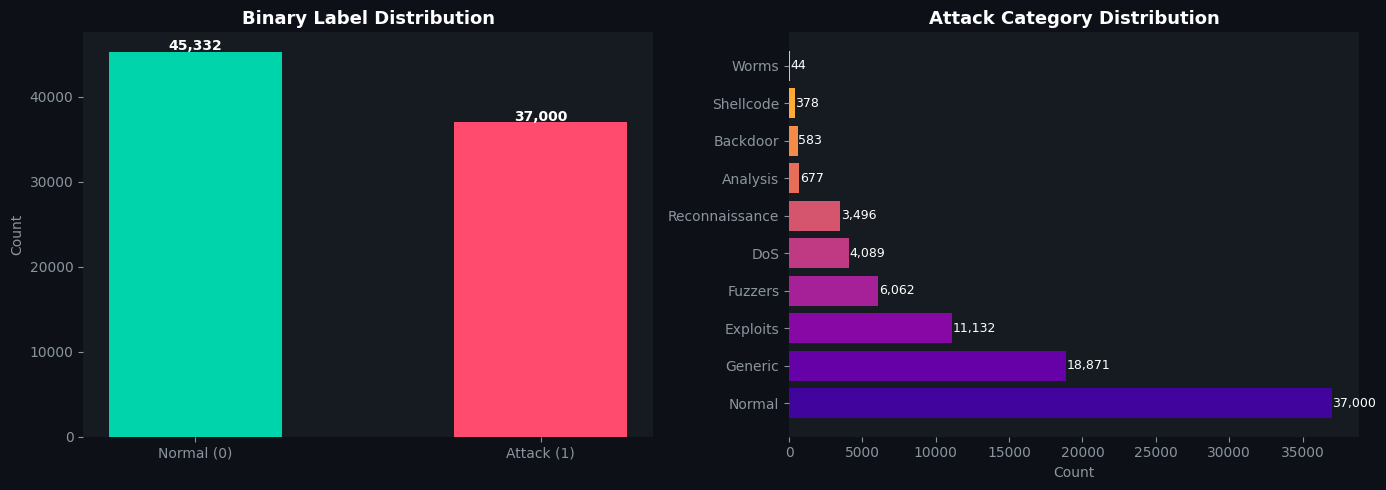

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0D1117')

# Binary label
label_counts = train_df['label'].value_counts()
axes[0].set_facecolor('#161B22')
bars = axes[0].bar(['Normal (0)', 'Attack (1)'], label_counts.values,
                    color=['#00D4AA', '#FF4B6E'], width=0.5)
axes[0].set_title('Binary Label Distribution', color='white', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count', color='#8B949E')
axes[0].tick_params(colors='#8B949E')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', color='white', fontweight='bold')
axes[0].spines[['top','right','left','bottom']].set_visible(False)

# Attack category
cat_counts = train_df['attack_cat'].fillna('Normal').value_counts()
palette = plt.cm.plasma(np.linspace(0.1, 0.9, len(cat_counts)))
axes[1].set_facecolor('#161B22')
bars2 = axes[1].barh(cat_counts.index, cat_counts.values, color=palette)
axes[1].set_title('Attack Category Distribution', color='white', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count', color='#8B949E')
axes[1].tick_params(colors='#8B949E')
axes[1].spines[['top','right','left','bottom']].set_visible(False)
for bar, val in zip(bars2, cat_counts.values):
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', color='white', fontsize=9)

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()

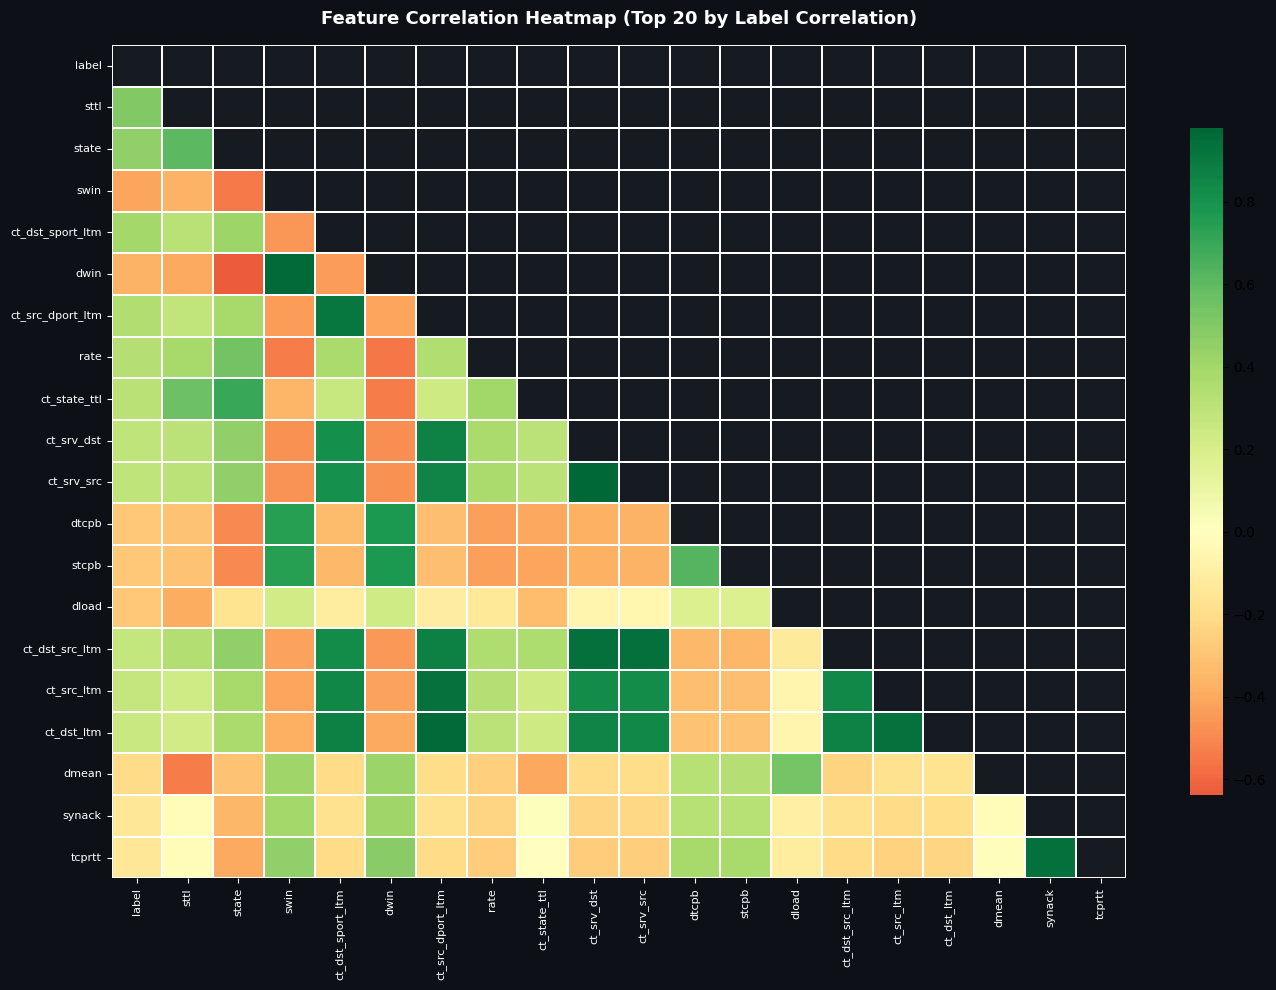


Top 10 features correlated with label:
sttl                0.504159
state               0.459040
swin                0.414504
ct_dst_sport_ltm    0.393668
dwin                0.369257
ct_src_dport_ltm    0.341513
rate                0.328629
ct_state_ttl        0.318517
ct_srv_dst          0.292931
ct_srv_src          0.290195
Name: label, dtype: float64


In [ ]:

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

numeric_df = train_clean.select_dtypes(include=[np.number])
corr_with_label = numeric_df.corr()['label'].abs().sort_values(ascending=False)
top_features = corr_with_label.head(20).index.tolist()
corr_matrix  = numeric_df[top_features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.3, cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Heatmap (Top 20 by Label Correlation)',
             color='white', fontsize=13, fontweight='bold', pad=15)
ax.tick_params(colors='white', labelsize=8)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()

print("\nTop 10 features correlated with label:")
print(corr_with_label.head(11).drop('label'))

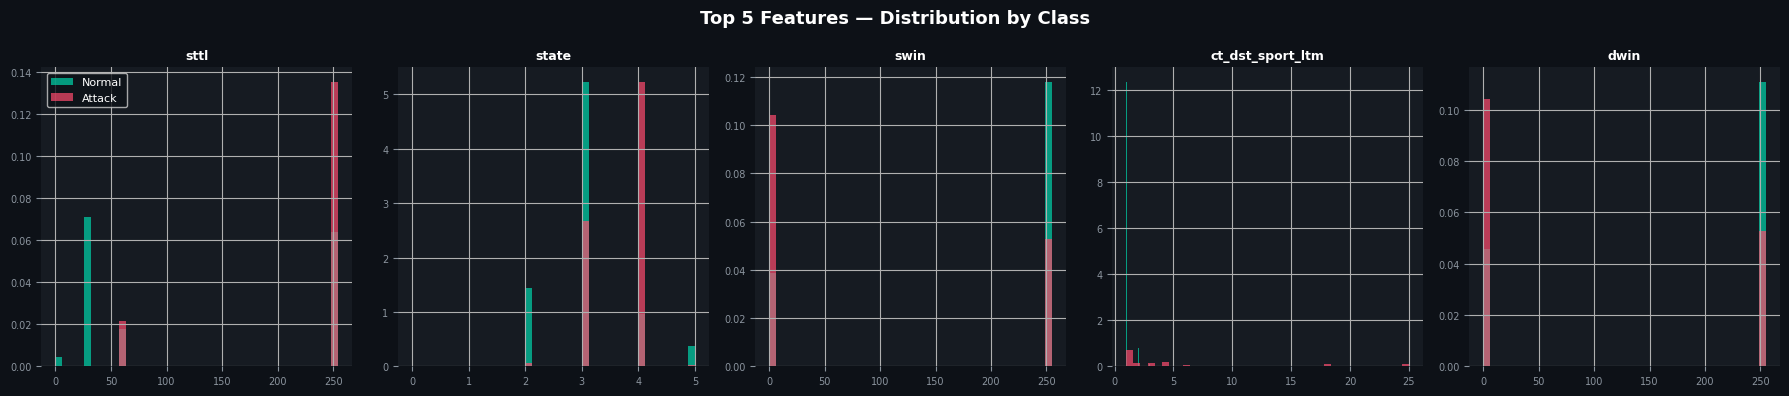

In [ ]:
top_5 = corr_with_label.index[1:6].tolist()  # skip 'label' itself

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('Top 5 Features — Distribution by Class', color='white', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, top_5):
    ax.set_facecolor('#161B22')
    cap = train_clean[feat].quantile(0.99)
    train_clean[train_clean['label']==0][feat].clip(upper=cap).hist(
        ax=ax, bins=40, alpha=0.7, color='#00D4AA', label='Normal', density=True)
    train_clean[train_clean['label']==1][feat].clip(upper=cap).hist(
        ax=ax, bins=40, alpha=0.7, color='#FF4B6E', label='Attack', density=True)
    ax.set_title(feat, color='white', fontsize=9, fontweight='bold')
    ax.tick_params(colors='#8B949E', labelsize=7)
    ax.spines[['top','right','left','bottom']].set_visible(False)

axes[0].legend(facecolor='#0D1117', labelcolor='white', fontsize=8)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()

In [ ]:
def engineer_features(df):
    X = df.copy()

    # 1. Byte ratio — asymmetric flows signal exfiltration or C2
    X['byte_ratio'] = X['sbytes'] / (X['dbytes'] + 1)

    # 2. Packet rate — bursts indicate DoS
    X['pkt_rate'] = (X['spkts'] + X['dpkts']) / (X['dur'] + 1e-6)

    # 3. Jitter asymmetry — timing attacks
    X['jit_asymmetry'] = np.abs(X['sjit'] - X['djit'])

    # 4. Connection density — repeated connections = scanning
    X['conn_density'] = X['ct_srv_src'] + X['ct_dst_ltm'] + X['ct_src_ltm']

    # 5. TTL difference — spoofed traffic indicator
    X['ttl_diff'] = np.abs(X['sttl'] - X['dttl'])

    return X


X_train_fe = engineer_features(X_train)
X_test_fe  = engineer_features(X_test)

print(f"Features before: {X_train.shape[1]}")
print(f"Features after:  {X_train_fe.shape[1]}")
print("\nNew features preview:")
print(X_train_fe[['byte_ratio','pkt_rate','jit_asymmetry','conn_density','ttl_diff']].describe().round(3))

Features before: 42
Features after:  47

New features preview:
       byte_ratio      pkt_rate  jit_asymmetry  conn_density   ttl_diff
count   82332.000  8.233200e+04      82332.000     82332.000  82332.000
mean      156.611  1.404170e+05       5859.466        21.760    132.921
std       951.237  2.419975e+05      54646.182        26.722    119.609
min         0.002  3.300000e-02          0.000         3.000      0.000
25%         0.940  3.134200e+01          0.000         6.000      2.000
50%        11.362  3.646308e+03          1.765        12.000    190.000
75%       114.000  2.222222e+05       2493.797        23.000    254.000
max     33728.000  2.000000e+07    1426091.685       178.000    255.000


In [ ]:
selector = SelectKBest(score_func=f_classif, k=30)
X_train_sel = selector.fit_transform(X_train_fe.fillna(0), y_train)
X_test_sel  = selector.transform(X_test_fe.fillna(0))

selected_features = X_train_fe.columns[selector.get_support()].tolist()
print(f"Selected {len(selected_features)} features:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f}")

scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_sel)
X_test_final  = scaler.transform(X_test_sel)

print(f"\nFinal — Train: {X_train_final.shape} | Test: {X_test_final.shape}")


Selected 30 features:
   1. service
   2. state
   3. rate
   4. sttl
   5. dttl
   6. sload
   7. dload
   8. sinpkt
   9. swin
  10. stcpb
  11. dtcpb
  12. dwin
  13. tcprtt
  14. synack
  15. ackdat
  16. dmean
  17. ct_srv_src
  18. ct_state_ttl
  19. ct_dst_ltm
  20. ct_src_dport_ltm
  21. ct_dst_sport_ltm
  22. ct_dst_src_ltm
  23. ct_flw_http_mthd
  24. ct_src_ltm
  25. ct_srv_dst
  26. is_sm_ips_ports
  27. byte_ratio
  28. pkt_rate
  29. conn_density
  30. ttl_diff

Final — Train: (82332, 30) | Test: (175341, 30)


=== OFFICIAL UNSW-NB15 SPLIT ===
Training : 82,332
Testing  : 175,341
Ratio    : 32% / 68%

Applying SMOTE...
After SMOTE — Normal: 45,332 | Attack: 45,332


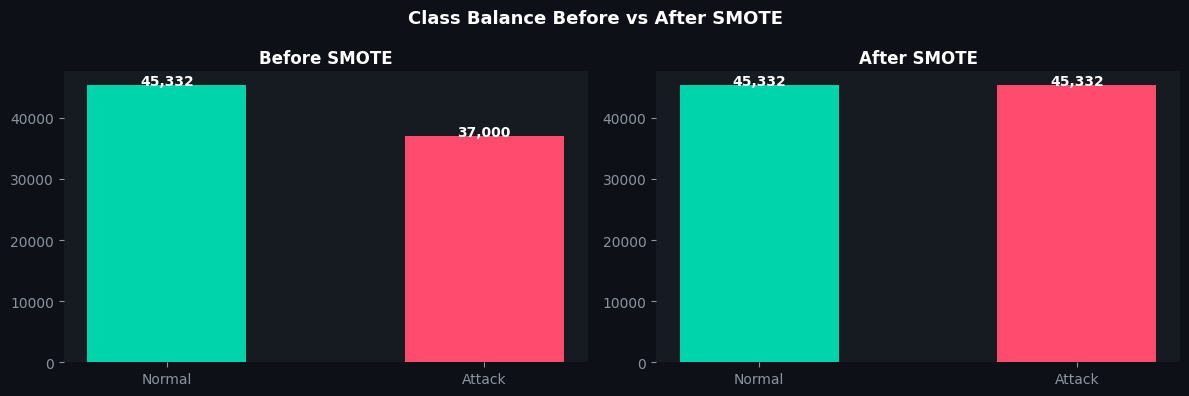

In [ ]:
print("=== OFFICIAL UNSW-NB15 SPLIT ===")
print(f"Training : {len(X_train_final):,}")
print(f"Testing  : {len(X_test_final):,}")
print(f"Ratio    : {len(X_train_final)/(len(X_train_final)+len(X_test_final)):.0%} / {len(X_test_final)/(len(X_train_final)+len(X_test_final)):.0%}")

print("\nApplying SMOTE...")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_final, y_train)

print(f"After SMOTE — Normal: {(y_train_smote==0).sum():,} | Attack: {(y_train_smote==1).sum():,}")

# Visualize before/after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0D1117')
for ax, data, title in zip(axes, [y_train, y_train_smote], ['Before SMOTE', 'After SMOTE']):
    ax.set_facecolor('#161B22')
    vc = pd.Series(data).value_counts()
    bars = ax.bar(['Normal', 'Attack'], vc.values, color=['#00D4AA','#FF4B6E'], width=0.5)
    ax.set_title(title, color='white', fontweight='bold')
    ax.tick_params(colors='#8B949E')
    ax.spines[['top','right','left','bottom']].set_visible(False)
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                f'{v:,}', ha='center', color='white', fontweight='bold')
plt.suptitle('Class Balance Before vs After SMOTE', color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_balance.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()

In [ ]:
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test_final)
y_prob_rf = rf.predict_proba(X_test_final)[:, 1]

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1  = f1_score(y_test, y_pred_rf, average='weighted')
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"\n{'='*40}")
print(f"  RANDOM FOREST RESULTS")
print(f"{'='*40}")
print(f"  Accuracy : {rf_acc:.4f}")
print(f"  F1-Score : {rf_f1:.4f}")
print(f"  ROC-AUC  : {rf_auc:.4f}")
print(f"{'='*40}")
print(classification_report(y_test, y_pred_rf, target_names=['Normal','Attack']))

Training Random Forest...

  RANDOM FOREST RESULTS
  Accuracy : 0.8944
  F1-Score : 0.8972
  ROC-AUC  : 0.9841
              precision    recall  f1-score   support

      Normal       0.76      0.98      0.86     56000
      Attack       0.99      0.86      0.92    119341

    accuracy                           0.89    175341
   macro avg       0.87      0.92      0.89    175341
weighted avg       0.92      0.89      0.90    175341



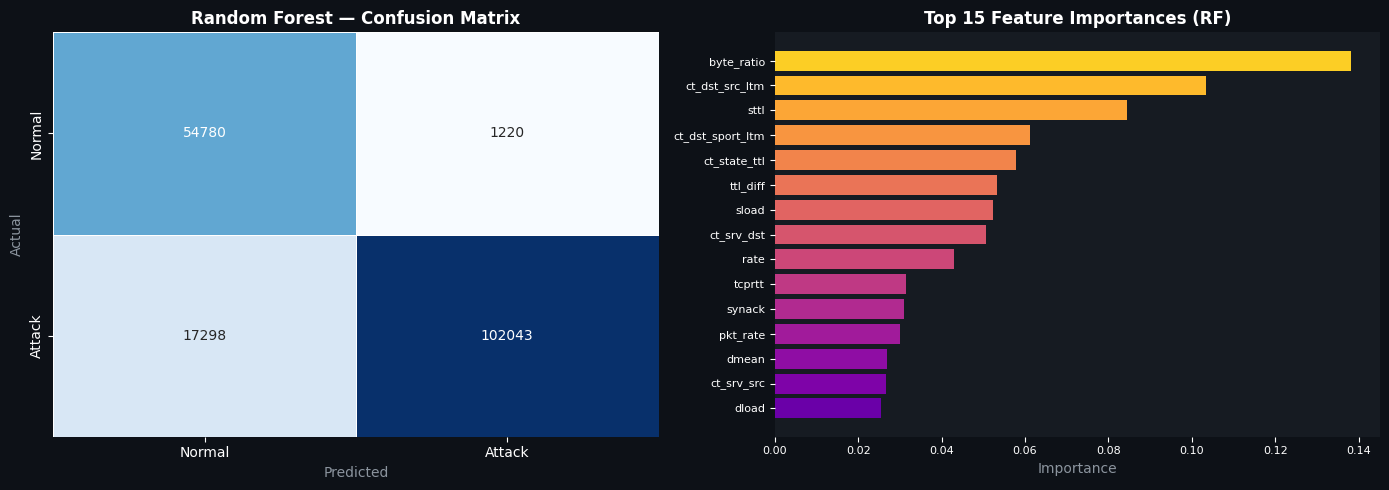

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0D1117')

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
axes[0].set_facecolor('#161B22')
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'],
            linewidths=0.5, cbar=False)
axes[0].set_title('Random Forest — Confusion Matrix', color='white', fontweight='bold')
axes[0].set_xlabel('Predicted', color='#8B949E')
axes[0].set_ylabel('Actual', color='#8B949E')
axes[0].tick_params(colors='white')

# Feature importances
feat_imp = pd.Series(rf.feature_importances_,
                     index=selected_features).sort_values(ascending=True).tail(15)
axes[1].set_facecolor('#161B22')
colors_imp = plt.cm.plasma(np.linspace(0.2, 0.9, len(feat_imp)))
axes[1].barh(feat_imp.index, feat_imp.values, color=colors_imp)
axes[1].set_title('Top 15 Feature Importances (RF)', color='white', fontweight='bold')
axes[1].tick_params(colors='white', labelsize=8)
axes[1].spines[['top','right','left','bottom']].set_visible(False)
axes[1].set_xlabel('Importance', color='#8B949E')

plt.tight_layout()
plt.savefig('rf_results.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()

X['byte_ratio'] = X['sbytes'] / (X['dbytes'] + 1)

    # 2. Packet rate — bursts indicate DoS
    X['pkt_rate'] = (X['spkts'] + X['dpkts']) / (X['dur'] + 1e-6)

    # 3. Jitter asymmetry — timing attacks
    X['jit_asymmetry'] = np.abs(X['sjit'] - X['djit'])

    # 4. Connection density — repeated connections = scanning
    X['conn_density'] = X['ct_srv_src'] + X['ct_dst_ltm'] + X['ct_src_ltm']

    # 5. TTL difference — spoofed traffic indicator
    X['ttl_diff'] = np.abs(X['sttl'] - X['dttl'])

In [ ]:
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False
)
xgb_model.fit(X_train_smote, y_train_smote,
              eval_set=[(X_test_final, y_test)],
              verbose=False)

y_pred_xgb = xgb_model.predict(X_test_final)
y_prob_xgb = xgb_model.predict_proba(X_test_final)[:, 1]

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1  = f1_score(y_test, y_pred_xgb, average='weighted')
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print(f"\n{'='*40}")
print(f"  XGBOOST RESULTS")
print(f"{'='*40}")
print(f"  Accuracy : {xgb_acc:.4f}")
print(f"  F1-Score : {xgb_f1:.4f}")
print(f"  ROC-AUC  : {xgb_auc:.4f}")
print(f"{'='*40}")
print(classification_report(y_test, y_pred_xgb, target_names=['Normal','Attack']))

Training XGBoost...

  XGBOOST RESULTS
  Accuracy : 0.8938
  F1-Score : 0.8966
  ROC-AUC  : 0.9845
              precision    recall  f1-score   support

      Normal       0.76      0.98      0.85     56000
      Attack       0.99      0.85      0.92    119341

    accuracy                           0.89    175341
   macro avg       0.87      0.92      0.89    175341
weighted avg       0.92      0.89      0.90    175341



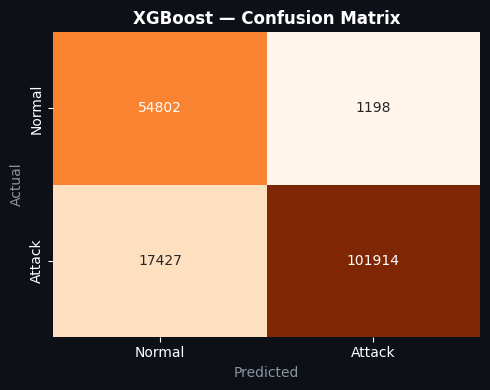


Computing SHAP values (this may take ~30 seconds)...


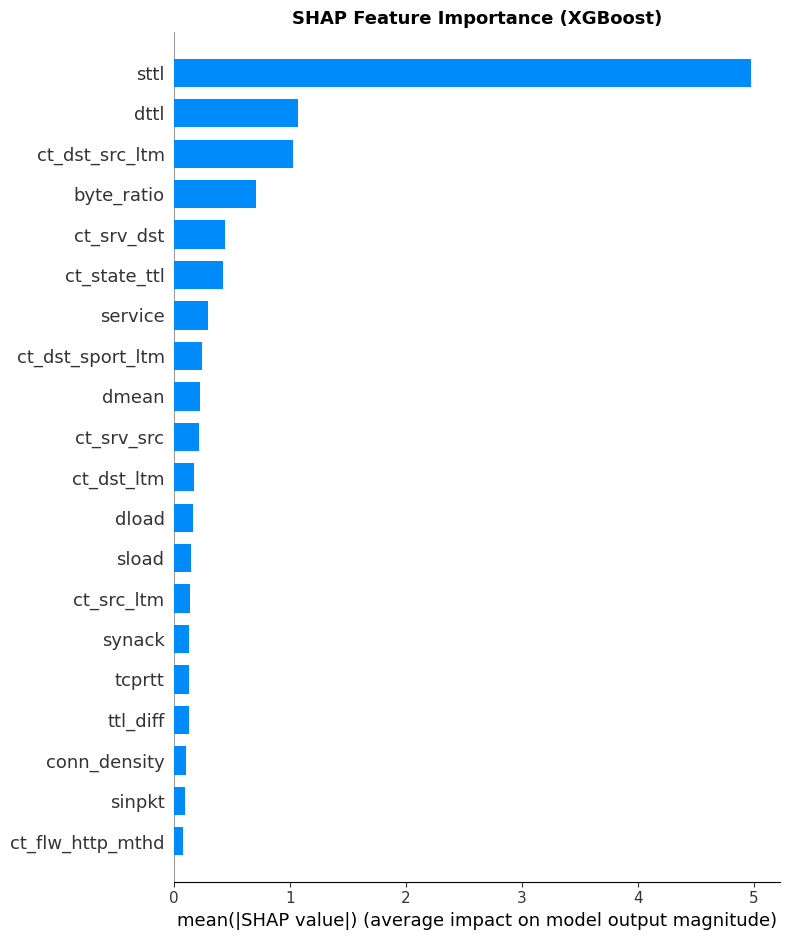

In [ ]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'], cbar=False)
ax.set_title('XGBoost — Confusion Matrix', color='white', fontweight='bold')
ax.set_xlabel('Predicted', color='#8B949E')
ax.set_ylabel('Actual', color='#8B949E')
ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig('xgb_cm.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()

# SHAP
print("\nComputing SHAP values (this may take ~30 seconds)...")
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_final[:500])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_final[:500],
                  feature_names=selected_features,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

X['byte_ratio'] = X['sbytes'] / (X['dbytes'] + 1)

    # 2. Packet rate — bursts indicate DoS
    X['pkt_rate'] = (X['spkts'] + X['dpkts']) / (X['dur'] + 1e-6)

    # 3. Jitter asymmetry — timing attacks
    X['jit_asymmetry'] = np.abs(X['sjit'] - X['djit'])

    # 4. Connection density — repeated connections = scanning
    X['conn_density'] = X['ct_srv_src'] + X['ct_dst_ltm'] + X['ct_src_ltm']

    # 5. TTL difference — spoofed traffic indicator
    X['ttl_diff'] = np.abs(X['sttl'] - X['dttl'])

In [ ]:
n_features = X_train_final.shape[1]

mlp = Sequential([
    Dense(256, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mlp.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nTraining MLP...")
history = mlp.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_test_final, y_test),
    epochs=50,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,737 (206.00 KB)

 Trainable params: 51,969 (203.00 KB)

 Non-trainable params: 768 (3.00 KB)


Training MLP...
Epoch 1/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8809 - loss: 0.2552 - val_accuracy: 0.8447 - val_loss: 0.3195
Epoch 2/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9254 - loss: 0.1740 - val_accuracy: 0.8576 - val_loss: 0.3090
Epoch 3/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9399 - loss: 0.1475 - val_accuracy: 0.8701 - val_loss: 0.3116
Epoch 4/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9464 - loss: 0.1343 - val_accuracy: 0.8815 - val_loss: 0.2941
Epoch 5/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9478 - loss: 0.1292 - val_accuracy: 0.8616 - val_loss: 0.3777
Epoch 6/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9515 - loss: 0.1229 - val_accuracy: 0.8785 - val_loss: 0.3243
Epoch 7/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9532 - loss: 0.1176 - val_accuracy: 0.8822 - val_loss: 0.3310
Epoch 8/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9537 - loss: 

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step

  MLP NEURAL NETWORK RESULTS
  Accuracy : 0.8954
  F1-Score : 0.8980
  ROC-AUC  : 0.9800
              precision    recall  f1-score   support

      Normal       0.77      0.97      0.86     56000
      Attack       0.98      0.86      0.92    119341

    accuracy                           0.90    175341
   macro avg       0.87      0.91      0.89    175341
weighted avg       0.91      0.90      0.90    175341



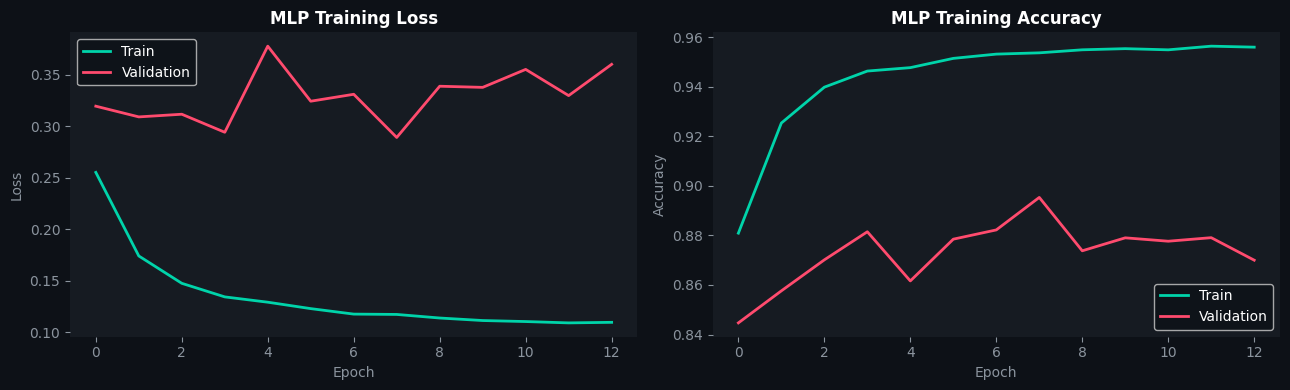

In [ ]:
y_prob_mlp = mlp.predict(X_test_final).flatten()
y_pred_mlp = (y_prob_mlp > 0.5).astype(int)

mlp_acc = accuracy_score(y_test, y_pred_mlp)
mlp_f1  = f1_score(y_test, y_pred_mlp, average='weighted')
mlp_auc = roc_auc_score(y_test, y_prob_mlp)

print(f"\n{'='*40}")
print(f"  MLP NEURAL NETWORK RESULTS")
print(f"{'='*40}")
print(f"  Accuracy : {mlp_acc:.4f}")
print(f"  F1-Score : {mlp_f1:.4f}")
print(f"  ROC-AUC  : {mlp_auc:.4f}")
print(f"{'='*40}")
print(classification_report(y_test, y_pred_mlp, target_names=['Normal','Attack']))

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0D1117')
for ax, metric, title in zip(axes, ['loss','accuracy'], ['Loss','Accuracy']):
    ax.set_facecolor('#161B22')
    ax.plot(history.history[metric],     color='#00D4AA', linewidth=2, label='Train')
    ax.plot(history.history[f'val_{metric}'], color='#FF4B6E', linewidth=2, label='Validation')
    ax.set_title(f'MLP Training {title}', color='white', fontweight='bold')
    ax.set_xlabel('Epoch', color='#8B949E')
    ax.set_ylabel(title, color='#8B949E')
    ax.tick_params(colors='#8B949E')
    ax.legend(facecolor='#0D1117', labelcolor='white')
    ax.spines[['top','right','left','bottom']].set_visible(False)
plt.tight_layout()
plt.savefig('mlp_training.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()

In [ ]:
results = pd.DataFrame({
    'Model':    ['Random Forest', 'XGBoost', 'MLP Neural Net'],
    'Accuracy': [rf_acc, xgb_acc, mlp_acc],
    'F1-Score': [rf_f1,  xgb_f1,  mlp_f1],
    'ROC-AUC':  [rf_auc, xgb_auc, mlp_auc]
}).set_index('Model')

print("=" * 52)
print("         MODEL COMPARISON RESULTS")
print("=" * 52)
print(results.round(4).to_string())
print("=" * 52)
best = results['F1-Score'].idxmax()
print(f"\n🏆 Best Model (F1): {best} → {results.loc[best,'F1-Score']:.4f}")

         MODEL COMPARISON RESULTS
                Accuracy  F1-Score  ROC-AUC
Model                                      
Random Forest     0.8944    0.8972   0.9841
XGBoost           0.8938    0.8966   0.9845
MLP Neural Net    0.8954    0.8980   0.9800

🏆 Best Model (F1): MLP Neural Net → 0.8980


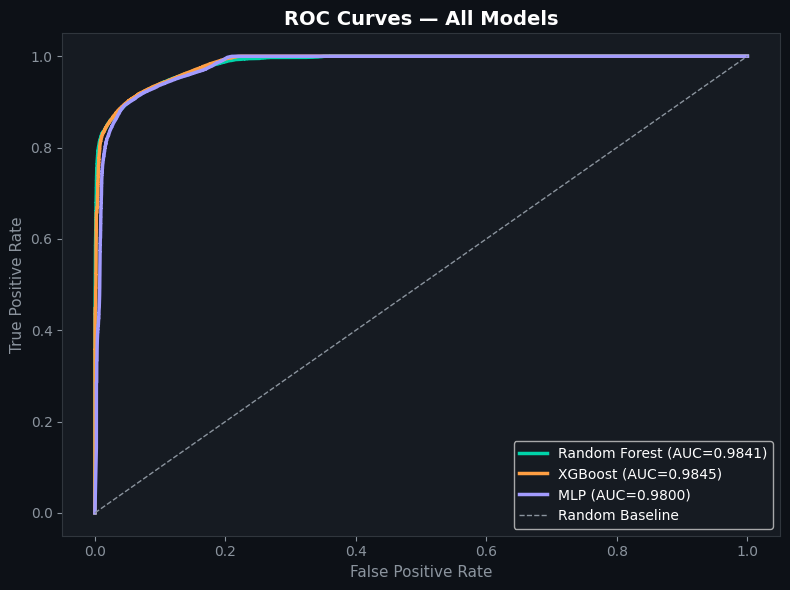

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

for name, y_prob, color in [
    ('Random Forest', y_prob_rf,  '#00D4AA'),
    ('XGBoost',       y_prob_xgb, '#FF9F43'),
    ('MLP',           y_prob_mlp, '#A29BFE')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2.5, color=color, label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0,1],[0,1], '--', color='#8B949E', linewidth=1, label='Random Baseline')
ax.set_xlabel('False Positive Rate', color='#8B949E', fontsize=11)
ax.set_ylabel('True Positive Rate',  color='#8B949E', fontsize=11)
ax.set_title('ROC Curves — All Models', color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='#8B949E')
ax.legend(facecolor='#161B22', labelcolor='white', fontsize=10)
ax.spines[['top','right','left','bottom']].set_color('#30363D')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()

---
## Part 2 — Multi-Class Classification (Attack Category)

The same feature matrix is re-used; only the target changes from binary `label`
to the 10-class `attack_cat` column (including **Normal** traffic).
SMOTE is applied per-class to handle severe imbalance.


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Applying SMOTE for multi-class...")
print("Class distribution before SMOTE:", Counter(y_train_mc))

smote_mc = SMOTE(random_state=42, k_neighbors=3)
X_train_smote_mc, y_train_smote_mc = smote_mc.fit_resample(X_train_final, y_train_mc)

print("Class distribution after SMOTE:", Counter(y_train_smote_mc))
print(f"\nTotal training samples: {len(X_train_smote_mc):,}")


Applying SMOTE for multi-class...
Class distribution before SMOTE: Counter({np.int64(6): 37000, np.int64(5): 18871, np.int64(3): 11132, np.int64(4): 6062, np.int64(2): 4089, np.int64(7): 3496, np.int64(0): 677, np.int64(1): 583, np.int64(8): 378, np.int64(9): 44})
Class distribution after SMOTE: Counter({np.int64(6): 37000, np.int64(7): 37000, np.int64(1): 37000, np.int64(2): 37000, np.int64(3): 37000, np.int64(0): 37000, np.int64(4): 37000, np.int64(9): 37000, np.int64(8): 37000, np.int64(5): 37000})

Total training samples: 370,000


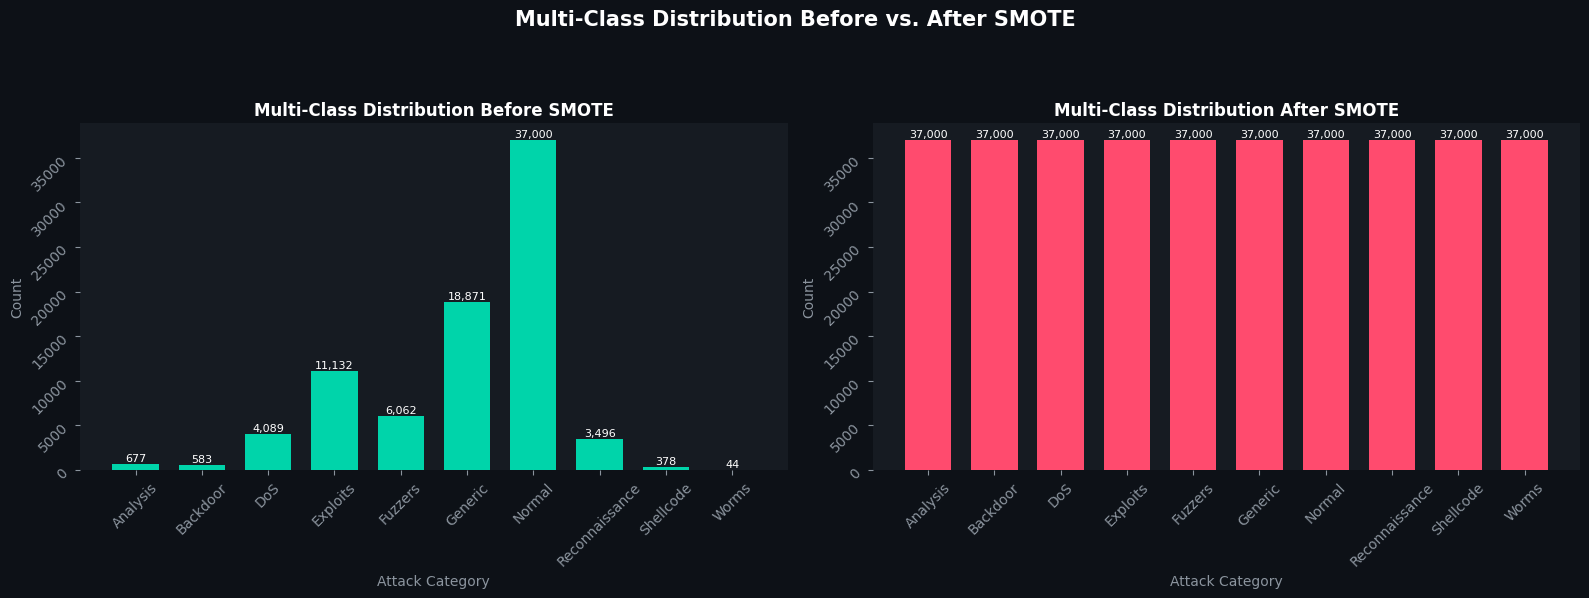

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# Before SMOTE
axes[0].set_facecolor('#161B22')
vc_before = pd.Series(y_train_mc).value_counts().sort_index()
bars_before = axes[0].bar(mc_classes[vc_before.index], vc_before.values, color='#00D4AA', width=0.7)
axes[0].set_title('Multi-Class Distribution Before SMOTE', color='white', fontweight='bold')
axes[0].set_xlabel('Attack Category', color='#8B949E')
axes[0].set_ylabel('Count', color='#8B949E')
axes[0].tick_params(colors='#8B949E', rotation=45)
axes[0].spines[['top','right','left','bottom']].set_visible(False)
for bar in bars_before:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 100, f'{yval:,}', ha='center', va='bottom', color='white', fontsize=8)

# After SMOTE
axes[1].set_facecolor('#161B22')
vc_after = pd.Series(y_train_smote_mc).value_counts().sort_index()
bars_after = axes[1].bar(mc_classes[vc_after.index], vc_after.values, color='#FF4B6E', width=0.7)
axes[1].set_title('Multi-Class Distribution After SMOTE', color='white', fontweight='bold')
axes[1].set_xlabel('Attack Category', color='#8B949E')
axes[1].set_ylabel('Count', color='#8B949E')
axes[1].tick_params(colors='#8B949E', rotation=45)
axes[1].spines[['top','right','left','bottom']].set_visible(False)
for bar in bars_after:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 100, f'{yval:,}', ha='center', va='bottom', color='white', fontsize=8)

plt.suptitle('Multi-Class Distribution Before vs. After SMOTE', color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('smote_mc_balance.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

print("Training Random Forest (multi-class)...")
rf_mc = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)
rf_mc.fit(X_train_smote_mc, y_train_smote_mc)

y_pred_rf_mc = rf_mc.predict(X_test_final)

rf_mc_acc = accuracy_score(y_test_mc, y_pred_rf_mc)
rf_mc_f1  = f1_score(y_test_mc, y_pred_rf_mc, average='weighted')

print(f"\n{'='*45}")
print(f"  RANDOM FOREST  (multi-class)  RESULTS")
print(f"{'='*45}")
print(f"  Accuracy : {rf_mc_acc:.4f}")
print(f"  F1 (wtd) : {rf_mc_f1:.4f}")
print(f"{'='*45}")
print(classification_report(y_test_mc, y_pred_rf_mc, target_names=mc_classes))


Training Random Forest (multi-class)...

  RANDOM FOREST  (multi-class)  RESULTS
  Accuracy : 0.7364
  F1 (wtd) : 0.7154
                precision    recall  f1-score   support

      Analysis       0.05      0.03      0.04      2000
      Backdoor       0.07      0.10      0.08      1746
           DoS       0.34      0.59      0.43     12264
      Exploits       0.85      0.49      0.62     33393
       Fuzzers       0.60      0.14      0.23     18184
       Generic       0.97      0.98      0.98     40000
        Normal       0.74      0.98      0.84     56000
Reconnaissance       0.79      0.76      0.78     10491
     Shellcode       0.37      0.69      0.48      1133
         Worms       0.11      0.44      0.17       130

      accuracy                           0.74    175341
     macro avg       0.49      0.52      0.47    175341
  weighted avg       0.76      0.74      0.72    175341



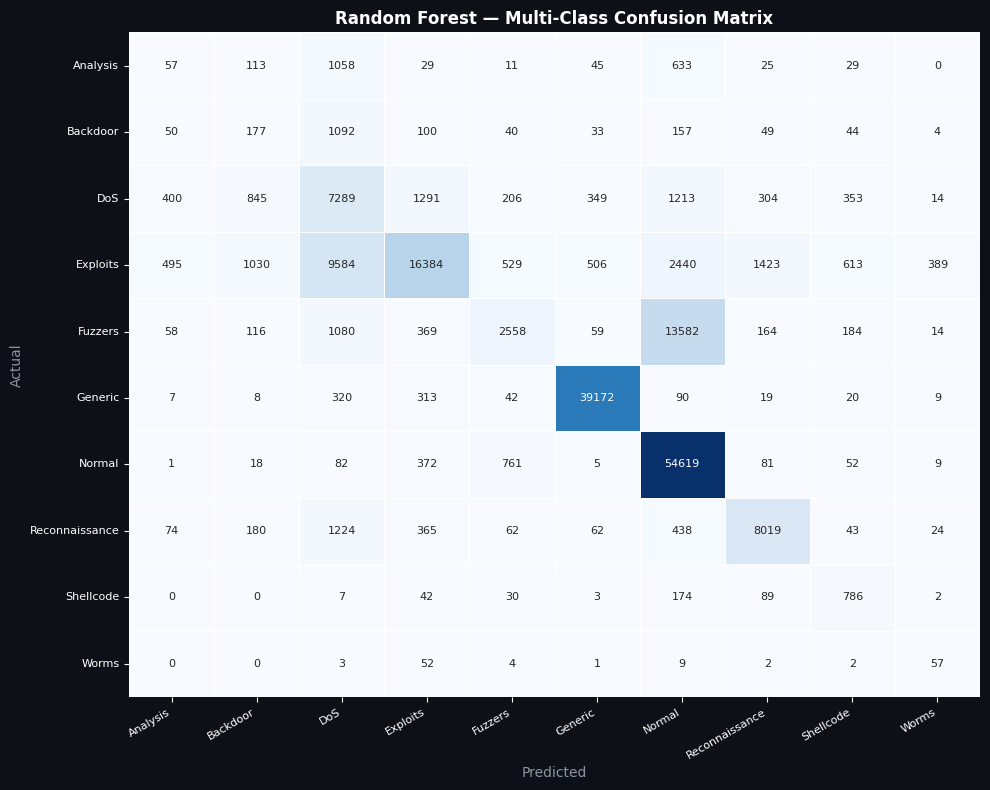

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')
cm_rf_mc = confusion_matrix(y_test_mc, y_pred_rf_mc)
sns.heatmap(cm_rf_mc, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=mc_classes, yticklabels=mc_classes,
            linewidths=0.5, cbar=False, annot_kws={'size': 8})
ax.set_title('Random Forest — Multi-Class Confusion Matrix', color='white', fontweight='bold')
ax.set_xlabel('Predicted', color='#8B949E')
ax.set_ylabel('Actual', color='#8B949E')
ax.tick_params(colors='white', labelsize=8)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('rf_mc_cm.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()


In [ ]:
print("Training XGBoost (multi-class)...")
n_classes = len(mc_classes)

xgb_mc = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=n_classes,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False
)
xgb_mc.fit(
    X_train_smote_mc, y_train_smote_mc,
    eval_set=[(X_test_final, y_test_mc)],
    verbose=False
)

y_pred_xgb_mc = xgb_mc.predict(X_test_final)

xgb_mc_acc = accuracy_score(y_test_mc, y_pred_xgb_mc)
xgb_mc_f1  = f1_score(y_test_mc, y_pred_xgb_mc, average='weighted')

print(f"\n{'='*45}")
print(f"  XGBOOST  (multi-class)  RESULTS")
print(f"{'='*45}")
print(f"  Accuracy : {xgb_mc_acc:.4f}")
print(f"  F1 (wtd) : {xgb_mc_f1:.4f}")
print(f"{'='*45}")
print(classification_report(y_test_mc, y_pred_xgb_mc, target_names=mc_classes))


Training XGBoost (multi-class)...

  XGBOOST  (multi-class)  RESULTS
  Accuracy : 0.7458
  F1 (wtd) : 0.7252
                precision    recall  f1-score   support

      Analysis       0.05      0.03      0.03      2000
      Backdoor       0.10      0.08      0.09      1746
           DoS       0.33      0.68      0.45     12264
      Exploits       0.82      0.51      0.63     33393
       Fuzzers       0.59      0.13      0.21     18184
       Generic       0.99      0.98      0.98     40000
        Normal       0.76      0.97      0.86     56000
Reconnaissance       0.86      0.78      0.82     10491
     Shellcode       0.37      0.70      0.49      1133
         Worms       0.21      0.45      0.29       130

      accuracy                           0.75    175341
     macro avg       0.51      0.53      0.48    175341
  weighted avg       0.77      0.75      0.73    175341



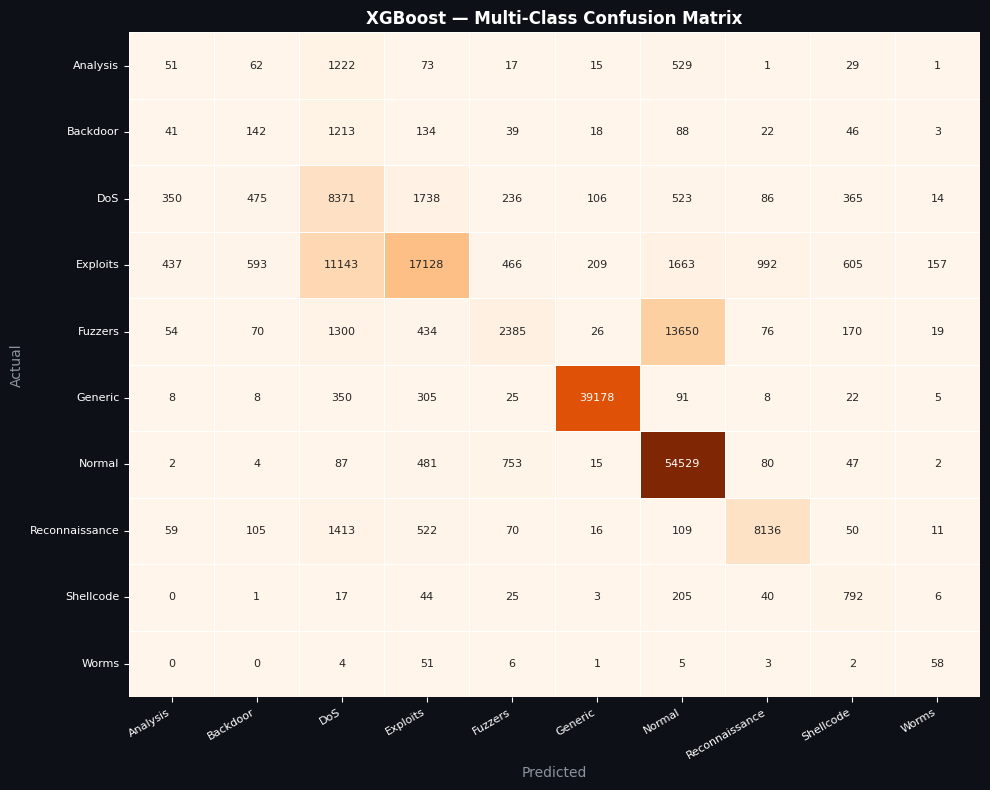

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')
cm_xgb_mc = confusion_matrix(y_test_mc, y_pred_xgb_mc)
sns.heatmap(cm_xgb_mc, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=mc_classes, yticklabels=mc_classes,
            linewidths=0.5, cbar=False, annot_kws={'size': 8})
ax.set_title('XGBoost — Multi-Class Confusion Matrix', color='white', fontweight='bold')
ax.set_xlabel('Predicted', color='#8B949E')
ax.set_ylabel('Actual', color='#8B949E')
ax.tick_params(colors='white', labelsize=8)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('xgb_mc_cm.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()


In [ ]:
from tensorflow.keras.utils import to_categorical

n_features_mc = X_train_final.shape[1]
n_classes     = len(mc_classes)

y_train_mc_oh = to_categorical(y_train_smote_mc, num_classes=n_classes)
y_test_mc_oh  = to_categorical(y_test_mc,        num_classes=n_classes)

mlp_mc = Sequential([
    Dense(256, activation='relu', input_shape=(n_features_mc,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')
])

mlp_mc.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
mlp_mc.summary()

early_stop_mc = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nTraining MLP (multi-class)...")
history_mc = mlp_mc.fit(
    X_train_smote_mc, y_train_mc_oh,
    validation_data=(X_test_final, y_test_mc_oh),
    epochs=50,
    batch_size=512,
    callbacks=[early_stop_mc],
    verbose=1
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,034 (207.16 KB)

 Trainable params: 52,266 (204.16 KB)

 Non-trainable params: 768 (3.00 KB)


Training MLP (multi-class)...
Epoch 1/50
723/723 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.5712 - loss: 1.1456 - val_accuracy: 0.6985 - val_loss: 0.7915
Epoch 2/50
723/723 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.6480 - loss: 0.9043 - val_accuracy: 0.7061 - val_loss: 0.7760
Epoch 3/50
723/723 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.6680 - loss: 0.8406 - val_accuracy: 0.7098 - val_loss: 0.8243
Epoch 4/50
723/723 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.6779 - loss: 0.8087 - val_accuracy: 0.7134 - val_loss: 0.8052
Epoch 5/50
723/723 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.6871 - loss: 0.7872 - val_accuracy: 0.7095 - val_loss: 0.8127
Epoch 6/50
723/723 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6908 - loss: 0.7732 - val_accuracy: 0.7231 - val_loss: 0.7913
Epoch 7/50
723/723 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.6961 - loss: 0.7622 - val_accuracy: 0.7208 - val_loss: 0.8069


5480/5480 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step

  MLP NEURAL NETWORK  (multi-class)  RESULTS
  Accuracy : 0.7061
  F1 (wtd) : 0.7051
                precision    recall  f1-score   support

      Analysis       0.05      0.03      0.03      2000
      Backdoor       0.04      0.07      0.05      1746
           DoS       0.32      0.69      0.44     12264
      Exploits       0.85      0.40      0.54     33393
       Fuzzers       0.64      0.23      0.34     18184
       Generic       1.00      0.98      0.99     40000
        Normal       0.81      0.95      0.87     56000
Reconnaissance       0.59      0.42      0.49     10491
     Shellcode       0.11      0.79      0.20      1133
         Worms       0.02      0.44      0.04       130

      accuracy                           0.71    175341
     macro avg       0.44      0.50      0.40    175341
  weighted avg       0.77      0.71      0.71    175341



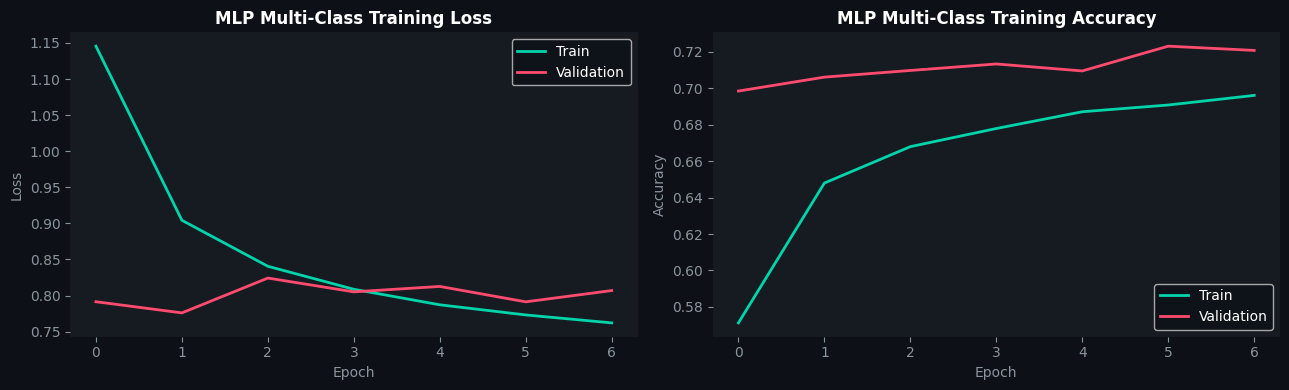

In [ ]:
y_pred_mlp_mc = np.argmax(mlp_mc.predict(X_test_final), axis=1)

mlp_mc_acc = accuracy_score(y_test_mc, y_pred_mlp_mc)
mlp_mc_f1  = f1_score(y_test_mc, y_pred_mlp_mc, average='weighted')

print(f"\n{'='*45}")
print(f"  MLP NEURAL NETWORK  (multi-class)  RESULTS")
print(f"{'='*45}")
print(f"  Accuracy : {mlp_mc_acc:.4f}")
print(f"  F1 (wtd) : {mlp_mc_f1:.4f}")
print(f"{'='*45}")
print(classification_report(y_test_mc, y_pred_mlp_mc, target_names=mc_classes))

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0D1117')
for ax, metric, title in zip(axes, ['loss','accuracy'], ['Loss','Accuracy']):
    ax.set_facecolor('#161B22')
    ax.plot(history_mc.history[metric],       color='#00D4AA', linewidth=2, label='Train')
    ax.plot(history_mc.history[f'val_{metric}'], color='#FF4B6E', linewidth=2, label='Validation')
    ax.set_title(f'MLP Multi-Class Training {title}', color='white', fontweight='bold')
    ax.set_xlabel('Epoch', color='#8B949E')
    ax.set_ylabel(title, color='#8B949E')
    ax.tick_params(colors='#8B949E')
    ax.legend(facecolor='#0D1117', labelcolor='white')
    ax.spines[['top','right','left','bottom']].set_visible(False)
plt.tight_layout()
plt.savefig('mlp_mc_training.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()


   MULTI-CLASS MODEL COMPARISON RESULTS
                Accuracy  F1 (wtd)
Model                             
Random Forest     0.7364    0.7154
XGBoost           0.7458    0.7252
MLP Neural Net    0.7061    0.7051

🏆 Best Multi-Class Model (F1): XGBoost → 0.7252


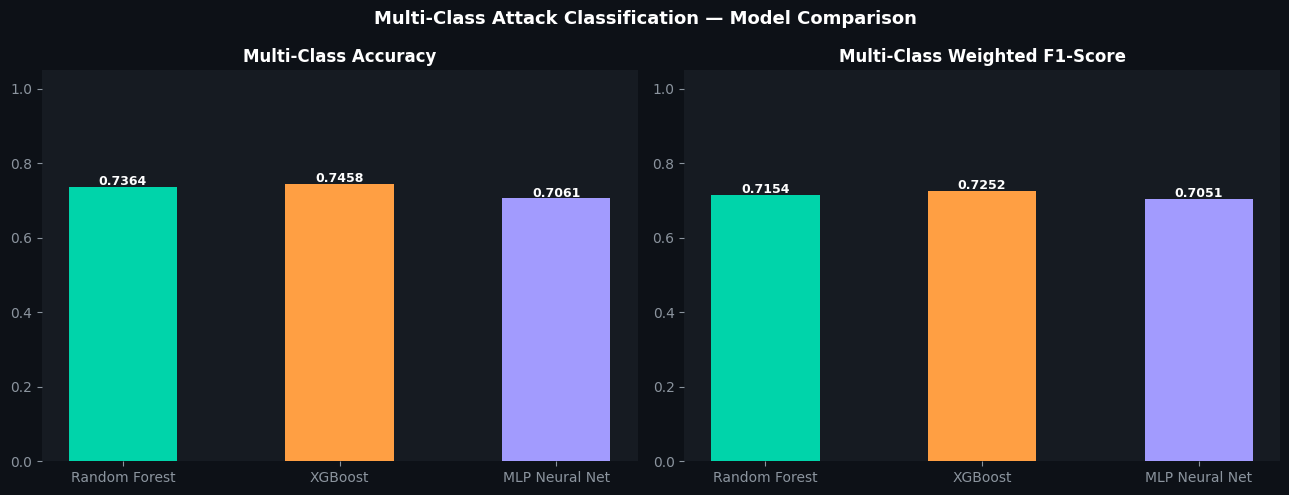

In [ ]:
results_mc = pd.DataFrame({
    'Model':    ['Random Forest', 'XGBoost', 'MLP Neural Net'],
    'Accuracy': [rf_mc_acc, xgb_mc_acc, mlp_mc_acc],
    'F1 (wtd)': [rf_mc_f1,  xgb_mc_f1,  mlp_mc_f1],
}).set_index('Model')

print("=" * 52)
print("   MULTI-CLASS MODEL COMPARISON RESULTS")
print("=" * 52)
print(results_mc.round(4).to_string())
print("=" * 52)
best_mc = results_mc['F1 (wtd)'].idxmax()
print(f"\n🏆 Best Multi-Class Model (F1): {best_mc} → {results_mc.loc[best_mc,'F1 (wtd)']:.4f}")

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0D1117')
for ax, col, title in zip(axes, ['Accuracy','F1 (wtd)'], ['Accuracy','Weighted F1-Score']):
    ax.set_facecolor('#161B22')
    colors = ['#00D4AA', '#FF9F43', '#A29BFE']
    bars = ax.bar(results_mc.index, results_mc[col], color=colors, width=0.5)
    ax.set_title(f'Multi-Class {title}', color='white', fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.tick_params(colors='#8B949E')
    ax.spines[['top','right','left','bottom']].set_visible(False)
    for bar, v in zip(bars, results_mc[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.4f}', ha='center', color='white', fontsize=9, fontweight='bold')
plt.suptitle('Multi-Class Attack Classification — Model Comparison',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('mc_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()


In [ ]:
print("=" * 60)
print("              FINAL PROJECT SUMMARY")
print("=" * 60)
print(f"  Dataset  : UNSW-NB15 (University of New South Wales)")
print(f"  Features : {n_features} (after engineering + selection)")
print(f"  Train    : {len(X_train_smote):,} samples (SMOTE balanced)")
print(f"  Test     : {len(X_test_final):,} samples")
print()
print("── Binary Classification ─────────────────────────────────")
print(results.round(4).to_string())
best_bin = results['F1-Score'].idxmax()
print(f"\n  🏆 Best Binary : {best_bin}")
print()
print("── Multi-Class Attack Classification ─────────────────────")
print(results_mc.round(4).to_string())
best_mc = results_mc['F1 (wtd)'].idxmax()
print(f"\n  🏆 Best Multi-Class : {best_mc}")
print("=" * 60)


              FINAL PROJECT SUMMARY
  Dataset  : UNSW-NB15 (University of New South Wales)
  Features : 30 (after engineering + selection)
  Train    : 90,664 samples (SMOTE balanced)
  Test     : 175,341 samples

── Binary Classification ─────────────────────────────────
                Accuracy  F1-Score  ROC-AUC
Model                                      
Random Forest     0.8944    0.8972   0.9841
XGBoost           0.8938    0.8966   0.9845
MLP Neural Net    0.8954    0.8980   0.9800

  🏆 Best Binary : MLP Neural Net

── Multi-Class Attack Classification ─────────────────────
                Accuracy  F1 (wtd)
Model                             
Random Forest     0.7364    0.7154
XGBoost           0.7458    0.7252
MLP Neural Net    0.7061    0.7051

  🏆 Best Multi-Class : XGBoost


In [ ]:
import shutil, os

output_dir = '/content/drive/MyDrive/CyberProject_Outputs'
os.makedirs(output_dir, exist_ok=True)

for f in ['eda_class_distribution.png', 'eda_correlation.png',
          'eda_distributions.png', 'smote_balance.png',
          'rf_results.png', 'xgb_cm.png', 'shap_importance.png',
          'mlp_training.png', 'roc_curves.png',
          'rf_mc_cm.png', 'xgb_mc_cm.png', 'mlp_mc_training.png',
          'mc_comparison.png']:
    if os.path.exists(f'/content/{f}'):
        shutil.copy(f'/content/{f}', output_dir)

print("✅ All outputs saved to Google Drive.")


✅ All outputs saved to Google Drive.
